In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Read the image
image = cv2.imread("cat.png")

# Convert BGR to RGB for displaying
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

In [3]:
# 1. Resizing / Zooming

# Increase image size by 2 times
zoomed = cv2.resize(
    image_rgb,
    None,
    fx=2,
    fy=2,
    interpolation=cv2.INTER_LINEAR
)

In [4]:
# 2. Rotation

# Get image dimensions
height, width = image_rgb.shape[:2]

# Find center of the image
center = (width // 2, height // 2)

# Create rotation matrix
rotation_matrix = cv2.getRotationMatrix2D(
    center,
    45,      # Rotation angle
    1.0      # Scale
)

# Apply rotation
rotated = cv2.warpAffine(
    image_rgb,
    rotation_matrix,
    (width, height)
)

In [5]:
# 3. Translation

# Translation values
tx = 100   # Move 100 pixels horizontally
ty = 50    # Move 50 pixels vertically

# Create translation matrix
translation_matrix = np.array([
    [1, 0, tx],
    [0, 1, ty]
], dtype=np.float32)

# Apply translation
translated = cv2.warpAffine(
    image_rgb,
    translation_matrix,
    (width, height)
)

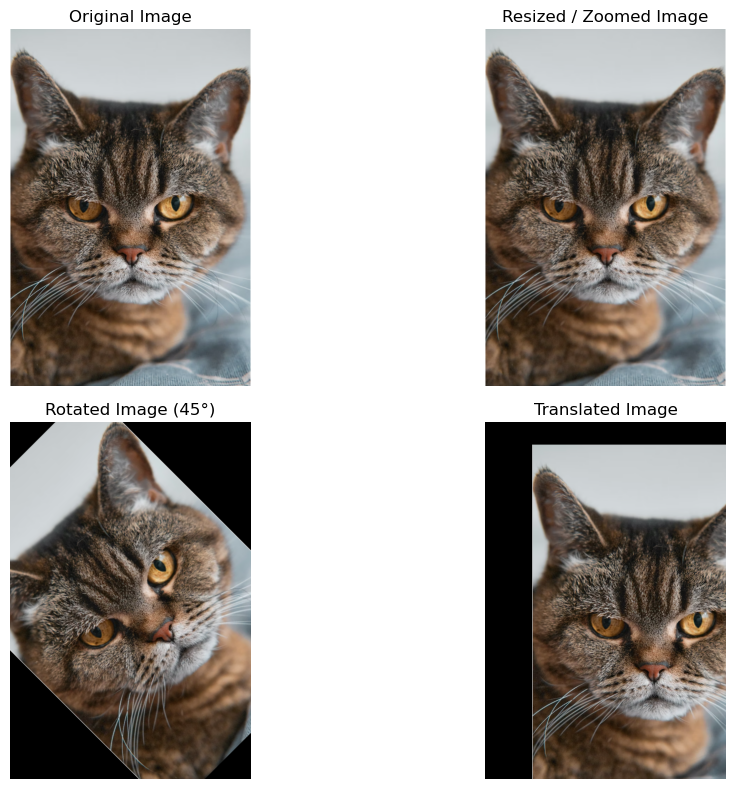

In [6]:
# Display Results

plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(zoomed)
plt.title("Resized / Zoomed Image")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(rotated)
plt.title("Rotated Image (45°)")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(translated)
plt.title("Translated Image")
plt.axis("off")

plt.tight_layout()
plt.show()